<a href="https://colab.research.google.com/github/YYM89/MSSP607/blob/main/Assignment_2_Yimeng_Yuan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Data cleaning

In [38]:
# === 0) Import & Config ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats
from pathlib import Path
from tabulate import tabulate
pd.set_option("display.max_columns", 60)


CSV_PATH = "/content/drive/MyDrive/MSSP607/Data/InternetSales.csv"
OUT_DIR = Path("figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def fmt_currency(x, pos):
    return f"${x:,.0f}"
currency_fmt = FuncFormatter(fmt_currency)


In [39]:
# === 1) Load data ===
df = pd.read_csv(CSV_PATH, encoding="cp1252", low_memory=False)
print("Shape:", df.shape)
df.head(3)


Shape: (60376, 61)


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,LastName,NameStyle,BirthDate,MaritalStatus,Suffix,Gender,EmailAddress,YearlyIncome,TotalChildren,NumberChildrenAtHome,EnglishEducation,SpanishEducation,FrenchEducation,EnglishOccupation,SpanishOccupation,FrenchOccupation,HouseOwnerFlag,NumberCarsOwned,AddressLine1,AddressLine2,...,DateFirstPurchase,CommuteDistance,ProductKey,EnglishProductName,OrderDateKey,DueDateKey,ShipDateKey,CustomerKey.1,PromotionKey,CurrencyKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,RevisionNumber,OrderQuantity,UnitPrice,ExtendedAmount,UnitPriceDiscountPct,DiscountAmount,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate,Unnamed: 60
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,Yang,FALSE,10/6/1971,M,NaN,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,NaN,...,1/19/2011,1-2 Miles,344,"Mountain-100 Silver, 38",20110119,20110131,20110126,11000,1,6.0,9,SO43793,1,1.0,1.0,3399.99,3399.99,0.0,0.0,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011,NaN
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,Yang,FALSE,10/6/1971,M,NaN,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,NaN,...,1/19/2011,1-2 Miles,353,"Mountain-200 Silver, 38",20130118,20130130,20130125,11000,2,6.0,9,SO51522,1,1.0,1.0,2319.99,2319.99,0.0,0.0,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013,NaN
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,Yang,FALSE,10/6/1971,M,NaN,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,NaN,...,1/19/2011,1-2 Miles,485,Fender Set - Mountain,20130118,20130130,20130125,11000,1,6.0,9,SO51522,2,1.0,1.0,21.98,21.98,0.0,0.0,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013,NaN


In [40]:

# === 2) Column mapping ===
country_col = "EnglishCountryRegionName" if "EnglishCountryRegionName" in df.columns else None
gender_raw  = "Gender" if "Gender" in df.columns else None
income_col  = "YearlyIncome" if "YearlyIncome" in df.columns else None
home_col    = "HouseOwnerFlag" if "HouseOwnerFlag" in df.columns else None
order_col   = "OrderDate" if "OrderDate" in df.columns else None
sales_col   = "SalesAmount" if "SalesAmount" in df.columns else None
price_col   = "UnitPrice" if "UnitPrice" in df.columns else None
product_col = "EnglishProductName" if "EnglishProductName" in df.columns else None
customer_col= "CustomerKey" if "CustomerKey" in df.columns else None
region_code_col= "CountryRegionCode" if "CountryRegionCode" in df.columns else None
Ordernum_col = "OrderQuantity" if "OrderQuantity" in df.columns else None
print(dict(country_col=country_col, gender_raw=gender_raw, income_col=income_col,
           home_col=home_col, order_col=order_col, sales_col=sales_col,
           price_col=price_col, product_col=product_col, customer_col=customer_col))


{'country_col': 'EnglishCountryRegionName', 'gender_raw': 'Gender', 'income_col': 'YearlyIncome', 'home_col': 'HouseOwnerFlag', 'order_col': 'OrderDate', 'sales_col': 'SalesAmount', 'price_col': 'UnitPrice', 'product_col': 'EnglishProductName', 'customer_col': 'CustomerKey'}


In [41]:

# === 3) Basic cleaning ===
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip()

# Year
if order_col:
    df[order_col] = pd.to_datetime(df[order_col], errors="coerce")
    df["Year"] = df[order_col].dt.year

# ￥
for c in [income_col, sales_col, price_col, home_col]:
    if c and c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df.head(3)


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,LastName,NameStyle,BirthDate,MaritalStatus,Suffix,Gender,EmailAddress,YearlyIncome,TotalChildren,NumberChildrenAtHome,EnglishEducation,SpanishEducation,FrenchEducation,EnglishOccupation,SpanishOccupation,FrenchOccupation,HouseOwnerFlag,NumberCarsOwned,AddressLine1,AddressLine2,...,CommuteDistance,ProductKey,EnglishProductName,OrderDateKey,DueDateKey,ShipDateKey,CustomerKey.1,PromotionKey,CurrencyKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,RevisionNumber,OrderQuantity,UnitPrice,ExtendedAmount,UnitPriceDiscountPct,DiscountAmount,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate,Unnamed: 60,Year
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,nan,Jon,V,Yang,FALSE,10/6/1971,M,nan,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,nan,...,1-2 Miles,344,"Mountain-100 Silver, 38",20110119,20110131,20110126,11000,1,6.0,9,SO43793,1,1.0,1.0,3399.99,3399.99,0.0,0.0,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,nan,2011-01-19,1/31/2011,1/26/2011,nan,2011.0
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,nan,Jon,V,Yang,FALSE,10/6/1971,M,nan,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,nan,...,1-2 Miles,353,"Mountain-200 Silver, 38",20130118,20130130,20130125,11000,2,6.0,9,SO51522,1,1.0,1.0,2319.99,2319.99,0.0,0.0,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,nan,2013-01-18,1/30/2013,1/25/2013,nan,2013.0
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,nan,Jon,V,Yang,FALSE,10/6/1971,M,nan,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,nan,...,1-2 Miles,485,Fender Set - Mountain,20130118,20130130,20130125,11000,1,6.0,9,SO51522,2,1.0,1.0,21.98,21.98,0.0,0.0,8.2205,8.2205,21.98,1.7584,0.5495,NaN,nan,2013-01-18,1/30/2013,1/25/2013,nan,2013.0


In [49]:
# === 4) Gender cleaning (only F/M) ===
def normalize_gender(x):
    s = str(x).strip().lower()
    if s in {"f","female","fem","woman","w","女","女生","女的"}: return "F"
    if s in {"m","male","man","men","boy","b","男","男生","男的"}: return "M"
    if s == "0": return "F"
    if s == "1": return "M"
    import re
    letters = re.sub(r"[^a-z]", "", s)
    if letters.startswith("f"): return "F"
    if letters.startswith("m"): return "M"
    return None

if gender_raw:
    df["Gender_clean"] = df[gender_raw].apply(normalize_gender)
else:
    df["Gender_clean"] = None

# keep F/M
df = df.loc[df["Gender_clean"].isin(["F","M"])].copy()
print(df["Gender_clean"].value_counts(dropna=False))
df.head(3)

Gender_clean
M    30319
F    30002
Name: count, dtype: int64


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,LastName,NameStyle,BirthDate,MaritalStatus,Suffix,Gender,EmailAddress,YearlyIncome,TotalChildren,NumberChildrenAtHome,EnglishEducation,SpanishEducation,FrenchEducation,EnglishOccupation,SpanishOccupation,FrenchOccupation,HouseOwnerFlag,NumberCarsOwned,AddressLine1,AddressLine2,...,ProductKey,EnglishProductName,OrderDateKey,DueDateKey,ShipDateKey,CustomerKey.1,PromotionKey,CurrencyKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,RevisionNumber,OrderQuantity,UnitPrice,ExtendedAmount,UnitPriceDiscountPct,DiscountAmount,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate,Unnamed: 60,Year,Gender_clean
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,nan,Jon,V,Yang,FALSE,10/6/1971,M,nan,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,nan,...,344,"Mountain-100 Silver, 38",20110119,20110131,20110126,11000,1,6.0,9,SO43793,1,1.0,1.0,3399.99,3399.99,0.0,0.0,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,nan,2011-01-19,1/31/2011,1/26/2011,nan,2011,M
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,nan,Jon,V,Yang,FALSE,10/6/1971,M,nan,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,nan,...,353,"Mountain-200 Silver, 38",20130118,20130130,20130125,11000,2,6.0,9,SO51522,1,1.0,1.0,2319.99,2319.99,0.0,0.0,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,nan,2013-01-18,1/30/2013,1/25/2013,nan,2013,M
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,nan,Jon,V,Yang,FALSE,10/6/1971,M,nan,M,jon24@adventure-works.com,90000,2,0,Bachelors,Licenciatura,Bac + 4,Professional,Profesional,Cadre,1,0,3761 N. 14th St,nan,...,485,Fender Set - Mountain,20130118,20130130,20130125,11000,1,6.0,9,SO51522,2,1.0,1.0,21.98,21.98,0.0,0.0,8.2205,8.2205,21.98,1.7584,0.5495,NaN,nan,2013-01-18,1/30/2013,1/25/2013,nan,2013,M


## Internet sales by year for each Country Region

In [50]:
# SalesAmount
df[sales_col] = pd.to_numeric(df[sales_col], errors='coerce')
df['Year'] = pd.to_datetime(df[order_col], errors='coerce').dt.year.astype('Int64')
sales_by_country_year = df.groupby([country_col, 'Year'])[sales_col].agg([
    ('Total_Sales', 'sum')
]).reset_index()

sales_by_country_year = sales_by_country_year.sort_values(['Year', 'Total_Sales'], ascending=[True, False])

print("\n📊 Sales Sum by country and year：")
print(sales_by_country_year.to_string(index=False))


📊 Sales Sum by country and year：
EnglishCountryRegionName  Year  Total_Sales
               Australia  2010   20909.7800
           United States  2010   14833.8982
                  Canada  2010    3578.2700
                  France  2010    3399.9900
          United Kingdom  2010     699.0982
               Australia  2011 2309720.3532
           United States  2011 2229984.0545
                  Canada  2011  524267.9873
          United Kingdom  2011  358762.1935
                 Germany  2011  307491.4873
                  France  2011  283513.0323
               Australia  2012 1907754.8600
           United States  2012 1340041.6341
          United Kingdom  2012  489841.7895
                  France  2012  396943.0700
                 Germany  2012  395046.8383
                  Canada  2012  296341.3360
           United States  2013 5179515.3048
               Australia  2013 4085639.1099
          United Kingdom  2013 1530377.7435
                 Germany  2013 1206899.484

Country/Region          2011        2012        2013
----------------  ----------  ----------  ----------
Australia         2309720.35  1907754.86  4085639.11
Canada             524267.99   296341.34  1018680.91
France             283513.03   396943.07  1066118.01
Germany            307491.49   395046.84  1206899.48
United Kingdom     358762.19   489841.79  1530377.74
United States     2229984.05  1340041.63  5179515.30


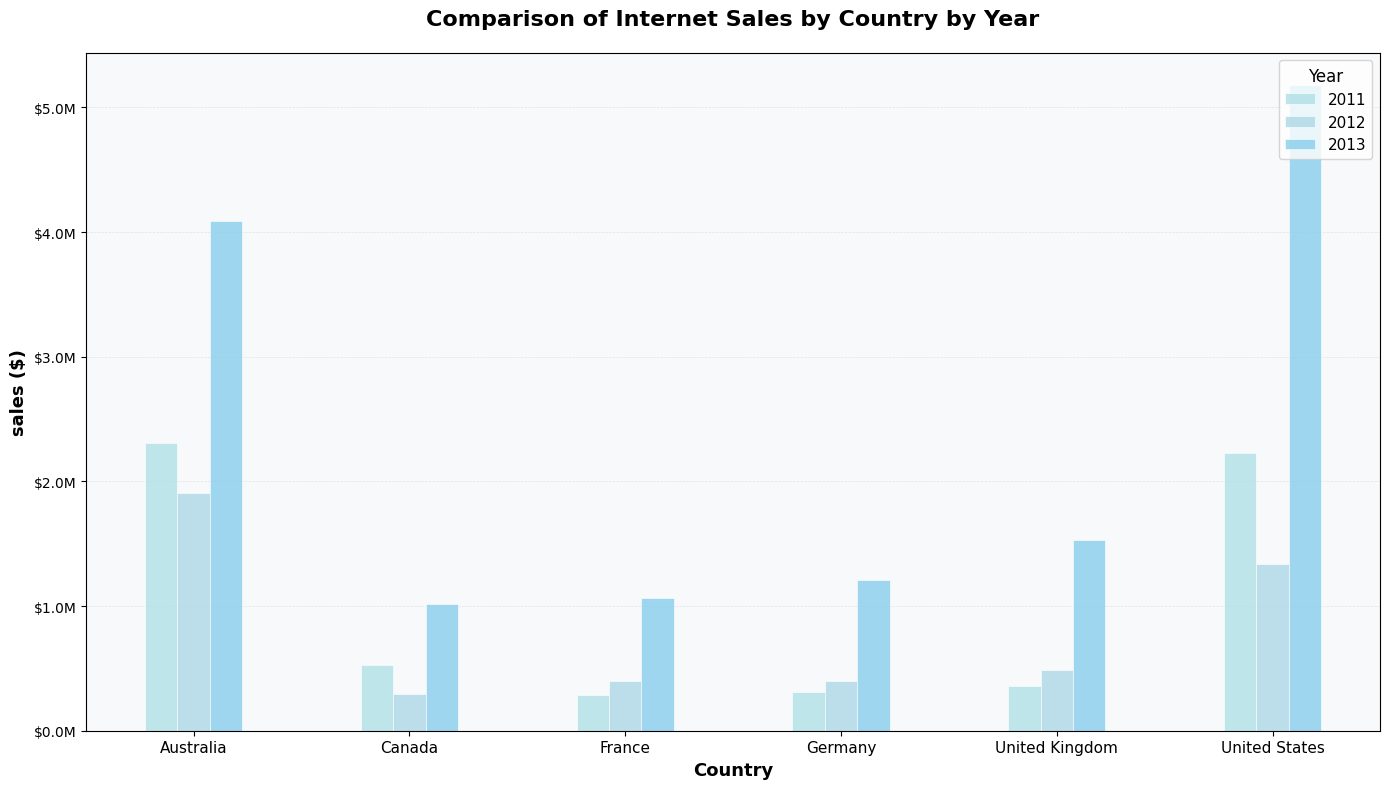


increaing trend：

Australia: 2.31M → 4.09M
  total increase: +76.9%
  yearly average increase: +38.4%

Canada: 0.52M → 1.02M
  total increase: +94.3%
  yearly average increase: +47.2%

France: 0.28M → 1.07M
  total increase: +276.0%
  yearly average increase: +138.0%

Germany: 0.31M → 1.21M
  total increase: +292.5%
  yearly average increase: +146.2%

United Kingdom: 0.36M → 1.53M
  total increase: +326.6%
  yearly average increase: +163.3%

United States: 2.23M → 5.18M
  total increase: +132.3%
  yearly average increase: +66.1%


In [51]:
df_filtered = df[~df['Year'].isin([2010, 2014])].copy()
sales_by_country_year = df_filtered.groupby([country_col, 'Year'])[sales_col].sum().reset_index()
sales_by_country_year.columns = ['Country', 'Year', 'Total_Sales']
pivot_data = sales_by_country_year.pivot(index='Country', columns='Year', values='Total_Sales')
pivot_apa = pivot_data.copy()
pivot_apa_reset = pivot_apa.reset_index()
pivot_apa_reset.columns = ['Country/Region'] + [str(int(year)) for year in pivot_apa_reset.columns[1:]]
print(tabulate(pivot_apa_reset,
               headers='keys',
               tablefmt='simple',
               showindex=False,
               floatfmt='.2f'))

# 3. 绘制分组柱状图
fig, ax = plt.subplots(figsize=(14, 8))

# 获取国家和年份
countries = pivot_data.index.tolist()
years = pivot_data.columns.tolist()
n_countries = len(countries)
n_years = len(years)

# 设置柱子宽度和位置
bar_width = 0.15  # 每根柱子的宽度
x = np.arange(n_countries)  # 国家的位置

# 为每一年绘制一组柱子
colors = ['powderblue', 'lightblue', 'skyblue']
for i, year in enumerate(years):
    # 计算每根柱子的偏移位置
    offset = (i - n_years/2 + 0.5) * bar_width
    values = pivot_data[year].fillna(0).values

    bars = ax.bar(x + offset, values, bar_width,
                   label=str(year),
                   color=colors[i % len(colors)],
                   alpha=0.8,
                   edgecolor='white',
                   linewidth=0.5)

# 4. 设置图表样式
ax.set_xlabel('Country', fontsize=13, fontweight='bold')
ax.set_ylabel('sales ($)', fontsize=13, fontweight='bold')
ax.set_title('Comparison of Internet Sales by Country by Year', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(countries, fontsize=11)
ax.legend(title='Year', fontsize=11, title_fontsize=12, loc='upper right')

# 格式化Y轴为百万美元
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# 添加网格线
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# 美化背景
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()


# 6. 计算并显示增长趋势
print("\n" + "=" * 70)
print("increaing trend：")
print("=" * 70)
for country in countries:
    country_sales = pivot_data.loc[country].dropna()
    if len(country_sales) > 1:
        total_growth = ((country_sales.iloc[-1] - country_sales.iloc[0]) / country_sales.iloc[0] * 100)
        print(f"\n{country}: {country_sales.iloc[0]/1e6:.2f}M → {country_sales.iloc[-1]/1e6:.2f}M")
        print(f"  total increase: {total_growth:+.1f}%")
        print(f"  yearly average increase: {total_growth/(len(country_sales)-1):+.1f}%")

In [52]:
country_summary = df.groupby(region_code_col)[sales_col].agg([
    ('Total_Sales', 'sum')
]).sort_values('Total_Sales', ascending=False)
country_summary['Percentage'] = (country_summary['Total_Sales'] / country_summary['Total_Sales'].sum() * 100).round(2)
print("\n📊 National Sales Summary：")
print(country_summary.round(2))


📊 National Sales Summary：
                   Total_Sales  Percentage
CountryRegionCode                         
US                  8781649.06       35.10
AU                  8332234.75       33.31
GB                  2384922.76        9.53
DE                  1913369.66        7.65
CA                  1850746.16        7.40
FR                  1753670.54        7.01


<Figure size 1000x2000 with 0 Axes>

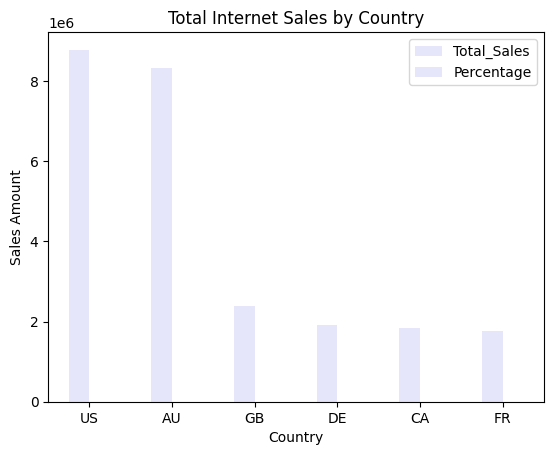

In [56]:
# Sum SalesAmount for each country across all years
if region_code_col and sales_col:
    plt.figure(figsize=(10, 20))
    ax = country_summary.plot(kind="bar", color='lavender')
    plt.title("Total Internet Sales by Country")
    plt.xlabel("Country")
    plt.ylabel("Sales Amount")
    plt.xticks(rotation=0, ha='center')

## Income By Country


,sum,mean,std,min,max
EnglishCountryRegionName,,,,,
Australia,883950000,66238.291495,31604.953236,10000,170000
United States,1388350000,65104.337632,26026.562525,10000,170000
Canada,456280000,60115.942029,21288.380564,10000,170000
United Kingdom,387700000,56139.588763,51043.678583,10000,170000
Germany,266590000,47444.385122,37524.648053,10000,130000
France,218920000,39544.797688,28493.181771,10000,110000


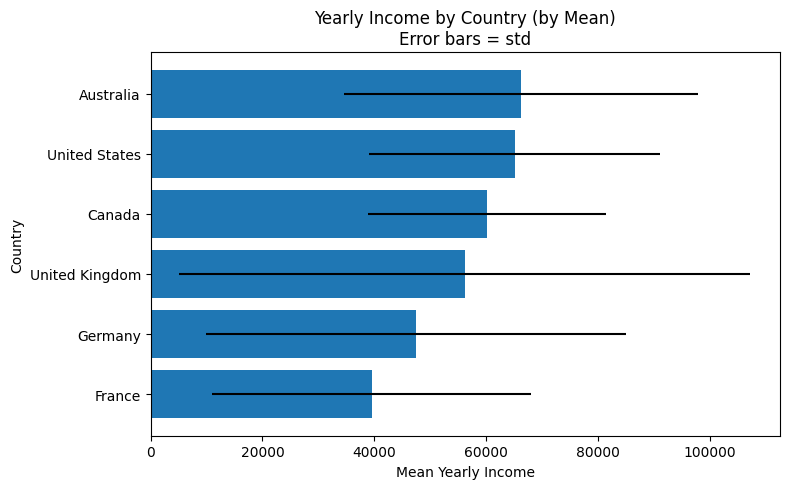

In [53]:
# Income stats
if country_col and income_col:
    inc = (df.dropna(subset=[country_col, income_col])
             .groupby(country_col)[income_col]
             .agg(sum="sum", mean="mean", std="std", min="min", max="max")
             .sort_values("mean", ascending=False))
    display(inc.head(15))

    # Plot: mean with std error bars
    Country = inc.head(10)
    fig, ax = plt.subplots(figsize=(8,5))
    ax.barh(Country.index, Country["mean"], xerr=Country["std"])
    ax.set_title("Yearly Income by Country (by Mean)\nError bars = std")
    ax.set_xlabel("Mean Yearly Income")
    ax.set_ylabel("Country")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Income stats skipped: missing columns.")



## Gender


PivotTable：
Gender                  F          M
Country                             
Australia       448300000  435650000
Canada          213960000  242320000
France          108640000  110280000
Germany         136170000  130420000
United Kingdom  192220000  195480000
United States   691840000  696510000


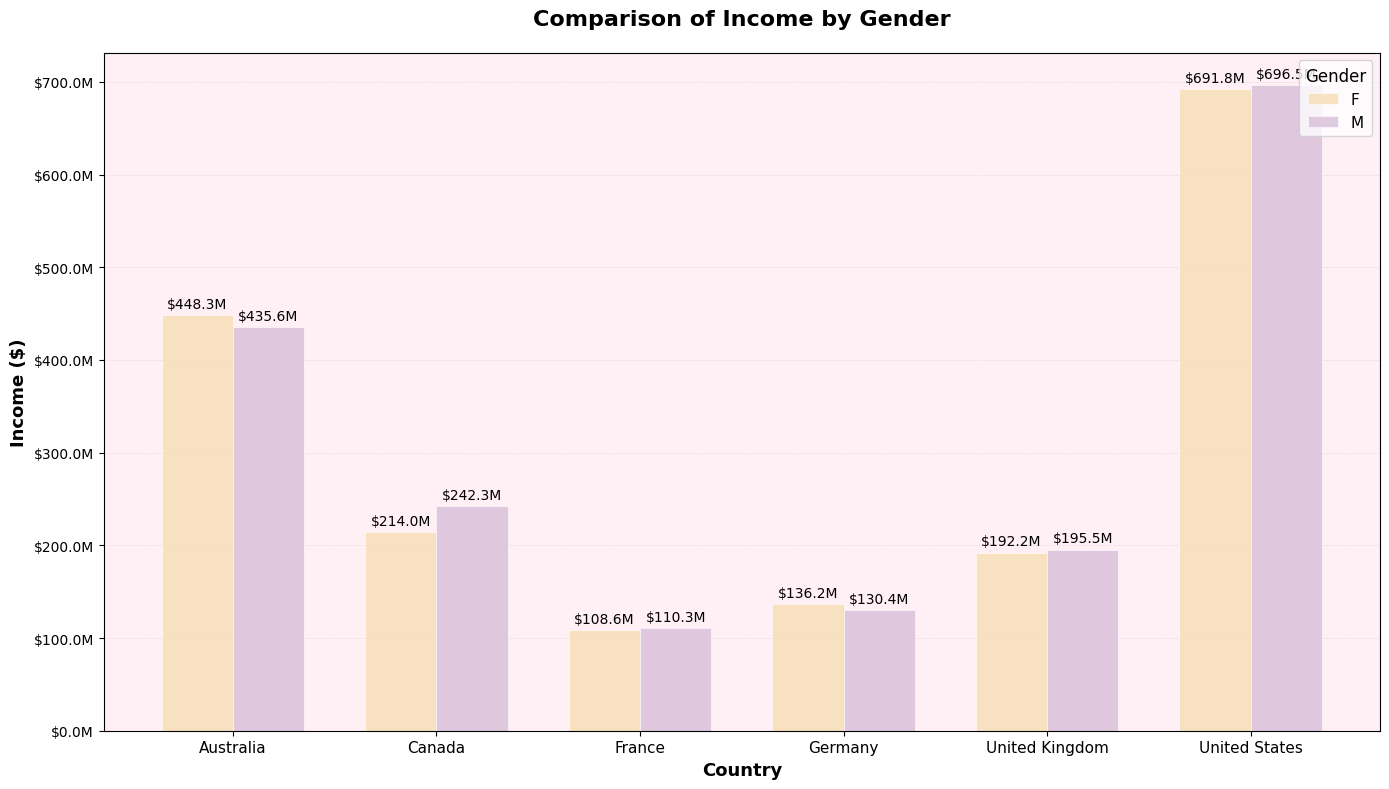

In [54]:
# Gender counts
income_by_Gender = df.groupby([country_col, df_gender_ok['Gender_clean']])[income_col].sum().reset_index()
income_by_Gender.columns = ['Country', 'Gender', 'Total_Income']
pivot_data = income_by_Gender.pivot(index='Country', columns='Gender', values='Total_Income')
print("\nPivotTable：")
print(pivot_data)


# 3. 绘制分组柱状图
fig, ax = plt.subplots(figsize=(14, 8))

# 获取国家和性别
countries = pivot_data.index.tolist()
gender = pivot_data.columns.tolist()
n_countries = len(countries)
n_gender = len(gender)

# 设置柱子宽度和位置
bar_width = 0.35 # Adjust bar width for two categories
x = np.arange(n_countries)  # 国家的位置

# 为每个性别绘制一组柱子
colors = ['wheat', 'thistle']
for i, gen in enumerate(gender): # Changed variable name from year to gen
    offset = (i - n_gender/2 + 0.5) * bar_width # Changed n_years to n_gender
    values = pivot_data[gen].fillna(0).values # Changed year to gen

    bars = ax.bar(x + offset, values, bar_width,
                   label=str(gen), # Changed year to gen
                   color=colors[i % len(colors)],
                   alpha=0.8,
                   edgecolor='white',
                   linewidth=0.5)
    # Add data labels
    ax.bar_label(bars, labels=[f'${v/1e6:.1f}M' for v in values], padding=3)


# 4. 设置图表样式
ax.set_xlabel('Country', fontsize=13, fontweight='bold')
ax.set_ylabel('Income ($)', fontsize=13, fontweight='bold')
ax.set_title('Comparison of Income by Gender', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(countries, fontsize=11)
ax.legend(title='Gender', fontsize=11, title_fontsize=12, loc='upper right')

# Format Y-axis to millions
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# 添加网格线
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# 美化背景
ax.set_facecolor('lavenderblush')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

## Housing

,count,mean,std,median
HouseOwnerFlag,,,,
0,6213,1306.546261,1982.005688,175.7100
1,11378,1479.491325,2120.395402,149.4600
2,834,75.574044,128.483782,6.0180
3,42,53.601086,107.362694,3.3164
4,7,12.675429,22.060689,5.5976


Welch t-test: t=-5.395, p=6.949e-08; Cohen's d=0.083


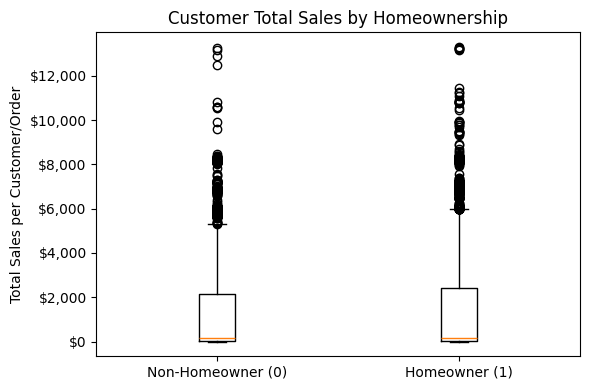

In [58]:
if home_col and sales_col:
    if customer_col:
        cust = (df.dropna(subset=[customer_col, home_col, sales_col])
                  .groupby([customer_col, home_col], as_index=False)[sales_col].sum())
        x = cust.copy()
    else:
        x = df.dropna(subset=[home_col, sales_col]).copy()

    # Summary
    grp = x.groupby(home_col)[sales_col].agg(count="count", mean="mean", std="std", median="median")
    display(grp)

    # Welch t-test
    a = x.loc[x[home_col]==0, sales_col].dropna().values
    b = x.loc[x[home_col]==1, sales_col].dropna().values
    if len(a)>1 and len(b)>1:
        t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        def cohen_d(a, b):
            a, b = np.array(a, dtype=float), np.array(b, dtype=float)
            na, nb = len(a), len(b)
            va, vb = a.var(ddof=1), b.var(ddof=1)
            pooled = ((na-1)*va + (nb-1)*vb) / (na+nb-2)
            return (a.mean() - b.mean()) / np.sqrt(pooled) if pooled>0 else np.nan
        d = cohen_d(b, a)  # homeowner(1) minus non-homeowner(0)
        print(f"Welch t-test: t={t:.3f}, p={p:.4g}; Cohen's d={d:.3f}")
    else:
        print("Insufficient data for t-test; showing distribution only.")

    # Boxplot
    fig, ax = plt.subplots(figsize=(6,4))
    data = [x.loc[x[home_col]==0, sales_col].dropna().values,
            x.loc[x[home_col]==1, sales_col].dropna().values]
    ax.boxplot(data, tick_labels=["Non-Homeowner (0)", "Homeowner (1)"], patch_artist=False)
    ax.set_title("Customer Total Sales by Homeownership")
    ax.set_ylabel("Total Sales per Customer/Order")
    ax.yaxis.set_major_formatter(currency_fmt)
    plt.tight_layout()
    plt.show()
else:
    print("Q4 skipped: missing HouseOwnerFlag/SalesAmount.")

In [ ]:
## Category

In [59]:
df[price_col] = pd.to_numeric(df[price_col], errors="coerce")
df[sales_col] = pd.to_numeric(df[sales_col], errors="coerce")
df[product_col] = df[product_col].astype(str)
sales_category = df.groupby(product_col).agg(
    Max_Unit_Price=(price_col, 'max'),
    Total_Sales_Amount=(sales_col, 'sum'),
    Avg_Sales_Amount=(sales_col, 'mean'),
).round(2).sort_values('Total_Sales_Amount', ascending=False)
print(sales_category.head(10))

                         Max_Unit_Price  Total_Sales_Amount  Avg_Sales_Amount
EnglishProductName                                                           
Mountain-200 Black, 42          2294.99          1208640.09           2221.76
Mountain-200 Black, 46          2294.99          1188804.82           2217.92
Mountain-200 Silver, 38         2319.99          1154857.87           2251.18
Mountain-200 Black, 38          2294.99          1123315.64           2224.39
Mountain-200 Silver, 46         2319.99          1108292.36           2243.51
Mountain-200 Silver, 42         2319.99          1090643.86           2248.75
Road-150 Red, 48                3578.27          1023385.22           3578.27
Road-150 Red, 62                3578.27           984024.25           3578.27
Road-150 Red, 52                3578.27           916037.12           3578.27
Road-150 Red, 56                3578.27           873097.88           3578.27
